1. CURRENLTY p=1 FIXED (DUE TO ONE-STEP PREDICTION ONLY) - FIX IT LATER
2. RESOLVE DECODER LIMITATION? HIDDEN_K SHOULD BE QUITE SMALL THAN NOW
3. NEW LOSS: A. MAG EIG = 1, B. DIST BTW MODE MAXIMIZE

Libraries

In [1]:
import os
import sys
sys.path.append('/dataset/')

import math
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from Autoencoder_functions import *
from torch.nn.utils import parameters_to_vector
from scipy.linalg import eig, inv
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils.stateless import functional_call
from tensorboard import notebook
from datetime import datetime

from tqdm import tqdm
from Autoencoder import KoopmanAutoencoder
from test_cartpole_function import *


Parameters

In [2]:
# Use GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cuda:0')
print('Currently using... '+str(device))

# Load pre-trained KAE?
load_model = False
load_model_name = 'Your_model_name.pt'

# KAE parameters
hidden_k = 10 # observable dim
kae_size = 64 # size of KAE
kae_coef = 0.75
lr_kae = 1e-4
num_epochs = 1000
training_data_size = 10000 # size of training dataset
batch_size = 512 # 128
c1, c2, c3 = 1, 1, 1 # KAE loss parameters
p = 1 # KAE prediction step
original_model_name = 'ppo_cartpole_policy.pt'



kae_classifier_coef = 1-kae_coef
Info = [kae_coef, hidden_k, 'CARTPOLE_v1']


Currently using... cpu


/home/joonwon/anaconda3/envs/koopman/lib/python3.13/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Fixed parameters & Initialization

load ppo_cartpole_policy.pt
testing model
Average reward over 20 episodes: 500.0
Rewards per episode: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]


KeyboardInterrupt: 

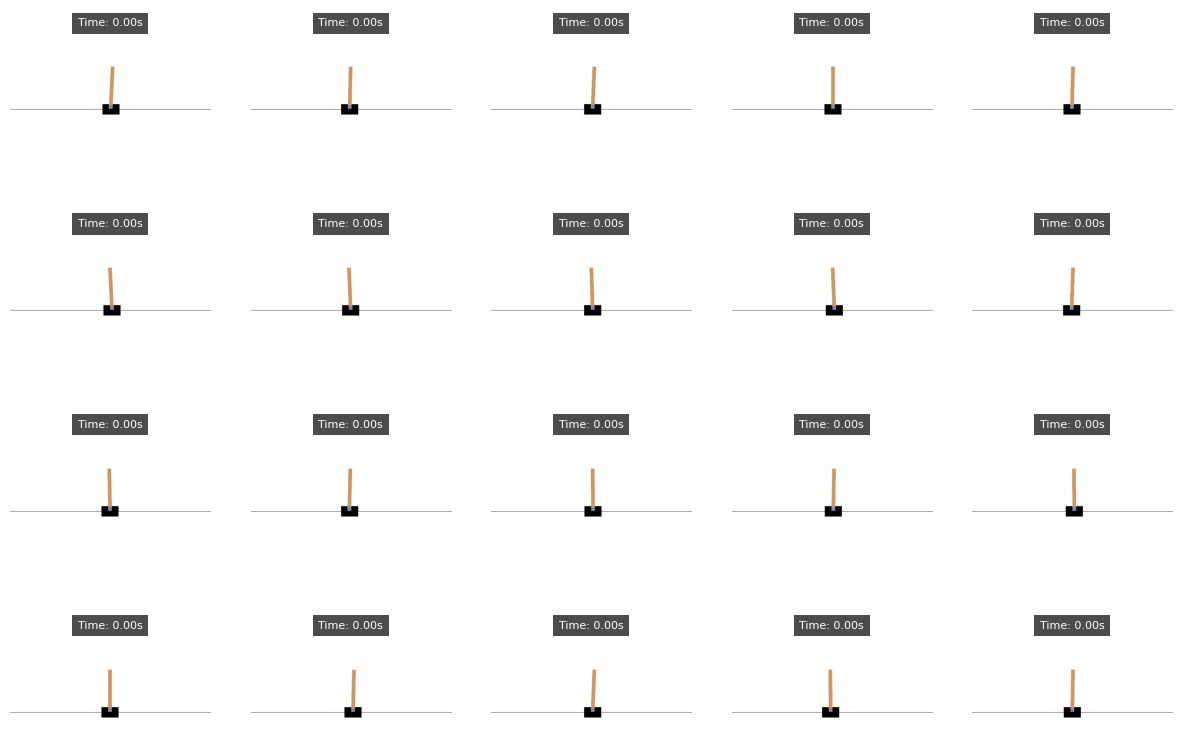

In [3]:
# Set training to be deterministic
seed = 10
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(seed)

## LOAD TRAINED MODEL

if os.path.isfile('../saved_models_re/originals/'+original_model_name):
    original_model = torch.load('../saved_models_re/originals/'+original_model_name, weights_only=False, map_location=device)
    print('load '+original_model_name)
    
    # TEST PERFORMANCE OF LOADED MODEL
    print('testing model')
    test_cartpole_function('../saved_models_re/originals/'+original_model_name, save_imgs=False)

else:
    print('ERROR, NO MODEL FOUND')

## UNDER CONSTRUCTION BELOW ###############################

# if os.path.isfile('results/classifier_'+str(target_dataset)+'_'+str(int(original_classifier_epoch))+'_'+str(int(training_data_size))+'.pth'):
#     classifier = torch.load('results/classifier_'+str(target_dataset)+'_'+str(int(original_classifier_epoch))+'_'+str(int(training_data_size))+'.pth', weights_only=False, map_location=device)
#     print('load '+str(target_dataset)+' classifier')
#     test_classifier(classifier, test_loader_classifier, device)

## LOAD TRAJECTORY DATA (OR GENERATE IT) + DEFINE AUGMENTED (=PADDED) DIMENSION

# if os.path.isfile('results/classifier_'+str(target_dataset)+'_'+str(int(original_classifier_epoch))+'_'+str(int(training_data_size))+'_training_data.pth'):
#     # LOAD existing dataset
#     data_dict = torch.load('results/classifier_'+str(target_dataset)+'_'+str(int(original_classifier_epoch))+'_'+str(int(training_data_size))+'_training_data.pth', map_location=device)
#     training_data = data_dict['training_data']
#     n , m = image_size, num_classes
#     l = max(n, m)
# else:
#     training_data = []
#     for i in range(training_data_size):
#         # Generate random inputs with MNIST bounds [-0.424, +2.821]
#         random_input = torch.rand(1, image_size, device=device) * (2.821 - (-0.424)) + (-0.424)
        
#         # Put the random input to trained model, extract output
#         outputs = classifier(random_input)

#         n, m = random_input.shape[1], outputs.shape[1]
#         l = max(n, m)

#         # Pad input and output with 1's to dimension l
#         pad_in = torch.ones(random_input.size(0), l - n, device=device)
#         pad_out = torch.ones(outputs.size(0), l - m, device=device)
#         aug_input = torch.cat([random_input, pad_in], dim=1)
#         aug_output = torch.cat([outputs, pad_out], dim=1)

#         # Save snapshot
#         training_data.append((aug_input.detach().cpu(), aug_output.detach().cpu()))

#     # Save the generated training data
#     torch.save({'training_data': training_data}, 'results/classifier_'+str(target_dataset)+'_'+str(int(original_classifier_epoch))+'_'+str(int(training_data_size))+'_training_data.pth')

# augmented_dimension = l

# # Build KAE
# state_dim = augmented_dimension
# kae = KoopmanAutoencoder(state_dim=state_dim, hidden_dim=kae_size, observable_dim = hidden_k).to(device)
# kae.train()
# criterion_kae = koopman_loss
# mse = torch.nn.MSELoss()
# optimizer_kae = optim.Adam(kae.parameters(), lr=lr_kae)
# kae.train()


Wandb

In [ ]:
# # Connect wandb
# current_date = datetime.now().strftime("%Y-%m-%d")

# wandb.init(project="Koopman_decomposition",
#            name = str(current_date),
#            config={
#             "lr_kae": lr_kae,
#             "lr_classifier": lr_classifier,
#             "num_epochs": num_epochs,
#             "batch_size": batch_size,
#             "p": p,
#             "c1": c1,
#             "c2": c2,
#             "c3": c3,
#             "target_dataset": target_dataset,
#             "hidden_c": hidden_c,
#             "training_data_size": training_data_size,
#             "original_classifier_epoch": original_classifier_epoch
#     })

Main training

In [ ]:
# KAE train data
train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)

# MNIST for classification loss
all_train_images = []
all_train_labels = []
all_test_images = []
all_test_labels = []

for imgs, lbls in train_loader_classifier:
    all_train_images.append(imgs)   # imgs: (B, 1, 28, 28)
    all_train_labels.append(lbls)   # lbls: (B,)

all_train_images = torch.cat(all_train_images, dim=0)   # (60000, 1, 28, 28)
all_train_labels = torch.cat(all_train_labels, dim=0)   # (60000,)
all_train_images = all_train_images.view(all_train_images.size(0), -1)   # (60000, 784)

for imgs, lbls in test_loader_classifier:
    all_test_images.append(imgs)   # imgs: (B, 1, 28, 28)
    all_test_labels.append(lbls)   # lbls: (B,)

all_test_images = torch.cat(all_test_images, dim=0)   # (10000, 1, 28, 28)
all_test_labels = torch.cat(all_test_labels, dim=0)   # (10000,)
all_test_images = all_test_images.view(all_test_images.size(0), -1)   # (10000, 784)

if load_model:
    kae = torch.load('results/kae_'+load_model_name, weights_only=False, map_location=device)
    kae.to(device)
    print('model loaded')

elif not load_model:
    best_acc = 0.0
    for epoch in (tq_var := tqdm(range(num_epochs), desc="Training")):
        running_loss = 0.0
        running_classifier_loss = 0.0

        # Each batch
        for inner, (aug_input, aug_output) in enumerate(train_loader):
            loss_kae_classifier = 0.0
            loss_kae = 0.0

            # loss_kae
            loss_kae, z = compute_l_kae(kae, aug_input, aug_output, c1, c2, c3, p, device) # Koopman operator is updated here.

            # N_O = z.shape[-1]
            # param_sub_all, eigvals = compute_theta_sub_all(kae, z, kae.K)
            # param_sub_kae = torch.sum(param_sub_all[:, :hidden_k], dim=1)        
                    
            # loss_kae_classifer           
            # model_shape, param_shapes = extract_model_structure_and_shapes(classifier)
            # loss_kae_classifier = compute_l_classifier_within(param_sub_kae.to(device), images, labels, criterion_classifier, model_shape, param_shapes, device)
            loss_kae_classifier = compute_l_classifier_within(all_train_images, all_train_labels, criterion_classifier, kae, num_classes, device)

            # Total loss
            loss = kae_coef * loss_kae + kae_classifier_coef * loss_kae_classifier

            # Update           
            optimizer_kae.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(kae.parameters(), max_norm=1.0)  # Add this line here
            optimizer_kae.step()
            running_loss = running_loss + loss.detach().cpu().item()

            # prof.step()

        # Wandb
        # wandb.log({
        #     "epoch": epoch,
        #     "train_loss": running_loss,
        #     "lr": optimizer_kae.param_groups[0]['lr']
        # })
        
        current_date = datetime.now().strftime("%Y-%m-%d") 
        waypoint_name = 'waypoints/waypoint_'+str(Info)+f'_{current_date}.pth'
        file_name = 'waypoints/KAE_'+str(Info)+f'_{current_date}.pth'
        # waypoint_name = 'waypoints/waypoint_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
        # file_name = 'waypoints/KAE_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
        #        

        acc = test_classifier_return(kae, all_test_images, all_test_labels, device, num_classes=num_classes)
        kae.train()

        if float(acc) > best_acc:
            torch.save({
            'epoch': epoch,
            'param_original': classifier.state_dict(),
            'param_kae': kae.state_dict(),
            'optimizer_state_dict': optimizer_kae.state_dict(),
            'ko': kae.K,
            'Info': Info
            }, waypoint_name)
            torch.save(kae, file_name)
            best_acc = acc
            print(f'Best accuracy updated: {best_acc:.4f} at epoch {epoch}')

        avg_loss = running_loss / len(train_loader_classifier)
        tq_var.set_description(f'Epoch [{epoch+1:4d}/{num_epochs}] | Loss: {avg_loss:.6f} | loss_kae: {loss_kae:.6f} | loss_kae_classifier: {loss_kae_classifier:.6f}')

        if math.isnan(running_loss/len(train_loader_classifier)):
            print('NAN detected')
            break
            
    current_date = datetime.now().strftime("%Y-%m-%d")
    waypoint_name = 'results/waypoint_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
    file_name = 'results/KAE_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
    torch.save({
    'epoch': epoch,
    'param_original': classifier.state_dict(),
    'param_kae': kae.state_dict(),
    'optimizer_state_dict': optimizer_kae.state_dict(),
    'ko': kae.K,
    'Info': Info
    }, waypoint_name)
    torch.save(kae, file_name) # save final model
    print(f'Iteration finished, loss = {running_loss/len(train_loader_classifier):.4f}')

    # wandb.finish()


In [ ]:
# load_model_name = "KAE_[0.75, 64, 'MNIST_DEEP']_1000_2025-08-25.pth"
# kae = torch.load('results/'+load_model_name, weights_only=False, map_location=device)
# kae.to(device)
# print('model loaded')

In [ ]:
import importlib
from Autoencoder_functions import *

%load_ext autoreload
%autoreload 2

# CHECK RECONSTRUCTION PERFORMANCE

print('Original classifier')
test_classifier(classifier, test_loader_classifier, device)

with torch.no_grad():
    print('Koopman Autoencoder')
    accuracy = test_classifier_return(kae, all_test_images, all_test_labels, device, num_classes=num_classes)
    print(accuracy)
    

    print('------------------------')
    # acc = test_classifier_return(kae, all_test_images, all_test_labels, device)
    kae.eval()
    N_O = hidden_k
    # stt_decomposed, eigvals = stt_decompose(kae, kae.encoder(all_test_images[-1,:]), 0)
    # eigvals_d = eigvals.cpu().detach()

    # reconstructed_output_wo_pad = torch.zeros([len(all_test_images),num_classes])
    reconstructed_output_wo_pad = []
    reconstructed_output_prop_wo_pad = []
    print(np.shape(reconstructed_output_wo_pad))
    for i in tqdm(range(0,len(all_test_images))):
        _,z,_ = kae(all_test_images[i,:])
        z_next = torch.matmul(z, kae.K.T)
        reconstructed_output = stt_decompose_reconstruction(kae, z, z_next, hidden_k, propagation=False)
        reconstructed_output_wo_pad.append(reconstructed_output[:num_classes])

        reconstructed_output_prop = stt_decompose_reconstruction(kae, z, z_next, hidden_k, propagation=True)
        reconstructed_output_prop_wo_pad.append(reconstructed_output_prop[:num_classes])

    reconstructed_output_wo_pad = torch.stack(reconstructed_output_wo_pad)
    reconstructed_output_wo_pad_real = reconstructed_output_wo_pad.real.detach()
    print('Reconstructed KAE accuracy ----')
    predicted = torch.argmax(reconstructed_output_wo_pad_real, dim=1)
    # print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
    correct = (predicted == all_test_labels).sum().item()
    total = all_test_labels.size(0)
    accuracy = 100.0 * correct / total
    print(accuracy)

    reconstructed_output_prop_wo_pad = torch.stack(reconstructed_output_prop_wo_pad)
    reconstructed_output_prop_wo_pad_real = reconstructed_output_prop_wo_pad.real.detach()
    print('Reconstructed KAE accuracy (eigval propagation) ----')
    predicted = torch.argmax(reconstructed_output_prop_wo_pad_real, dim=1)
    correct = (predicted == all_test_labels).sum().item()
    total = all_test_labels.size(0)
    accuracy = 100.0 * correct / total
    print(accuracy)

In [ ]:
import importlib
from Autoencoder_functions import *

%load_ext autoreload
%autoreload 2

sorted_labels, sorted_indices = torch.sort(all_test_labels)
all_test_images_sorted = all_test_images[sorted_indices]
all_test_labels_sorted = sorted_labels
per_label_test_images = {i: all_test_images[all_test_labels == i] for i in range(num_classes)}
per_label_test_labels = {i: all_test_labels[all_test_labels == i] for i in range(num_classes)}

with torch.no_grad():
    for j in range(0,hidden_k):
        result = []
        for cc in range(0,num_classes):
            reconstructed_output_wo_pad = []
            # reconstructed_output_prop_wo_pad = []
            for i in range(0,len(per_label_test_images[cc])):
                _,z,_ = kae(all_test_images[i,:])
                z_next = torch.matmul(z, kae.K.T)
                reconstructed_output = stt_decompose_mode(kae, z, z_next, hidden_k, j, propagation=True)
                reconstructed_output_wo_pad.append(reconstructed_output[:num_classes])

            reconstructed_output_wo_pad = torch.stack(reconstructed_output_wo_pad)
            reconstructed_output_wo_pad_real = reconstructed_output_wo_pad.real.detach()
            predicted = torch.argmax(reconstructed_output_wo_pad_real, dim=1)
            # print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
            correct = (predicted == per_label_test_labels[cc]).sum().item()
            total = all_test_labels.size(0)
            accuracy = 100.0 * correct / total
            result.append(accuracy)
        print(str(j)+"-th mode "+str(result))


In [ ]:

print()

predicted = torch.argmax(reconstructed_output_wo_pad, dim=1)
print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
print(np.shape(predicted))
correct = (predicted == all_test_labels).sum().item()
total = all_test_labels.size(0)
accuracy = 100.0 * correct / total
print(accuracy)

In [ ]:

    for idx_modes in tqdm(range(kae_size)):
        temp = np.zeros(num_classes)
        
        for idx_sub in range(num_classes):
            param_sub = param_sub_all[:, idx_modes]
            if target_dataset == 'MNIST_DEEP':
                classifier_sub_test = deepdeeper_MLP(image_size, hidden_c, num_classes).to(device)
            else:   
                classifier_sub_test = deeper_MLP(image_size, hidden_c, num_classes).to(device)
            classifier_sub_test.eval()
            nn.utils.vector_to_parameters(param_sub, classifier_sub_test.parameters())
            testloader = dataset_in_use_per_class.sub_testloaders[idx_sub]
            total = 0
            correct = 0
            for images, labels in testloader:
                images = images.reshape(-1, 28*28).to(device)
                labels = labels.to(device)
                outputs = classifier_sub_test(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            accuracy = 100 * correct / total
            temp[idx_sub] = accuracy
        formatted = np.array([num for num in temp])

        if idx_modes == 0:
            formatted_history = formatted
        else:
            formatted_history = np.vstack((formatted_history, formatted))

# Get best element
formatted_history2 = np.array(formatted_history, dtype=float)
bests = np.max(formatted_history2,axis = 0)
is_max = formatted_history2 == bests
row_counts = np.sum(is_max, axis = 1)

print('Best elements :')
print(bests)
print('Best counts :')
print(row_counts)

num_cols = formatted_history2.shape[1]
for col in range(num_cols):
    rows_with_max = np.where(formatted_history2[:,col] == bests[col])[0]
    print('------------')
    print(f'Class {col}: Best = {bests[col]}')
    for row_idx in rows_with_max:
        print(f'Mode {row_idx}: [|eig|={torch.linalg.norm(eigvals_d[row_idx])}] {np.array2string(formatted_history2[row_idx], precision=4)}')